In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')



# Find data.yaml automatically
import glob
yaml_files = glob.glob("/content/drive/MyDrive/Dataset-yolov8/**/*.yaml", recursive=True)
yaml_path = yaml_files[0]  # first YAML found
print("Using dataset YAML at:", yaml_path)


Mounted at /content/drive
Using dataset YAML at: /content/drive/MyDrive/Dataset-yolov8/data.yaml


In [ ]:
# Install PyTorch 2.x compatible with Colab GPU
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install latest ultralytics
!pip install ultralytics --upgrade


Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load YOLOv8 segmentation model
model = YOLO("yolov8n-seg.pt")

# Train and save directly to Drive
model.train(
    data="/content/drive/MyDrive/Dataset-yolov8/data.yaml",
    epochs=50,                     # start small for testing
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/yolov8_segmentation",  # ✅ saves to Drive
    name="my_seg_class_model",
    save_period=3
)


Ultralytics 8.3.210 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset-yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=my_seg_class_model2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7da858191cd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/drive/MyDrive/Dataset-yolov8/valid/images/000087_jpg.rf.6476ac7b2c8282124418015004be3fff.jpg: 640x640 1 zarda, 9.3ms
Speed: 5.1ms preprocess, 9.3ms inference, 380.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict_custom


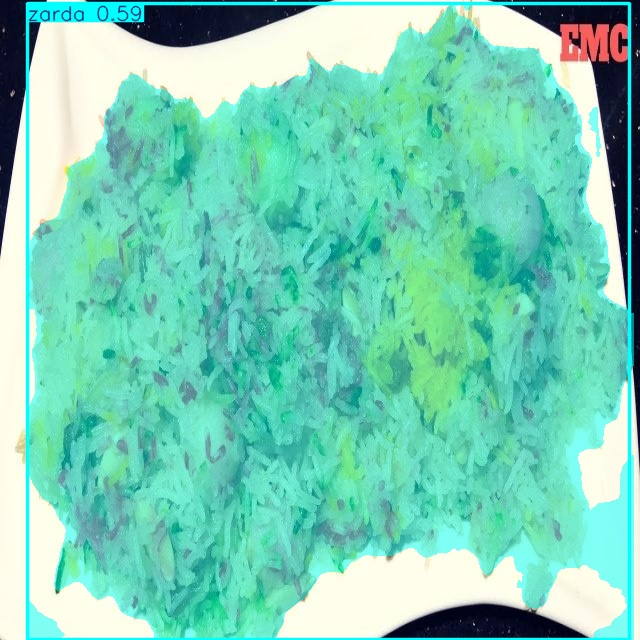


image 1/1 /content/drive/MyDrive/Dataset-yolov8/valid/images/000007_jpg.rf.14c6fdbfa0a64cbf84eaa475bf4d1c05.jpg: 640x640 1 chicken_biryani, 17.3ms
Speed: 3.1ms preprocess, 17.3ms inference, 7.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict_custom


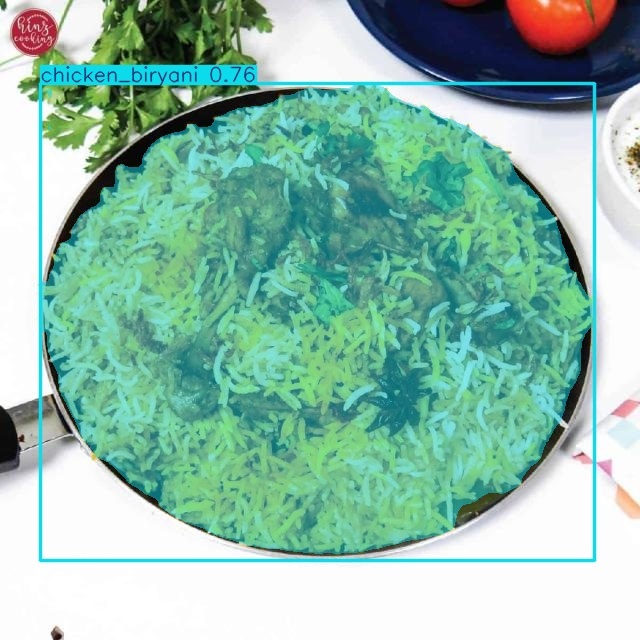


image 1/1 /content/drive/MyDrive/Dataset-yolov8/valid/images/000054_jpg.rf.b0ec7bf67fa7c501a0caa700aa831feb.jpg: 640x640 1 mutton_beef_biryani, 9.9ms
Speed: 1.7ms preprocess, 9.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict_custom


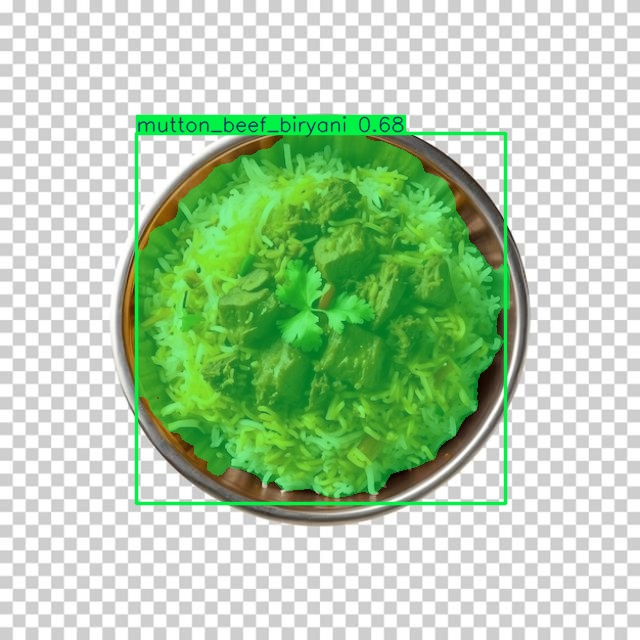


image 1/1 /content/drive/MyDrive/Dataset-yolov8/valid/images/000018_jpg.rf.2518d033c6fac03ece080f0dcdf3bc24.jpg: 640x640 1 zarda, 23.3ms
Speed: 4.2ms preprocess, 23.3ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict_custom


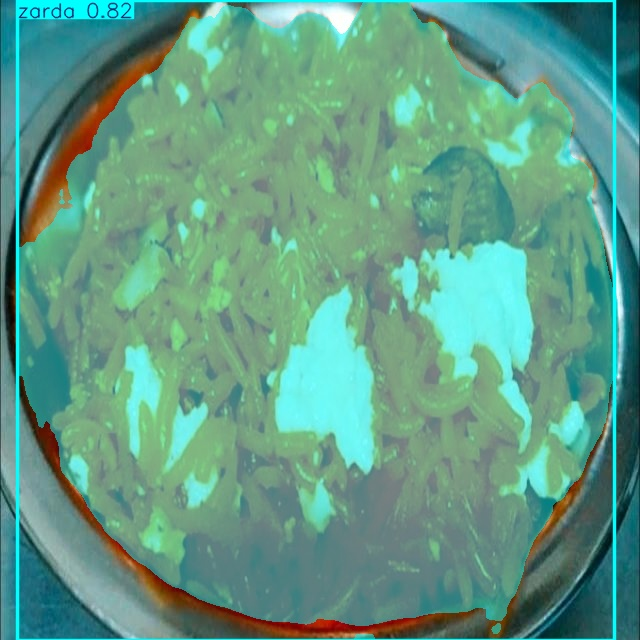


✅ Segmentation results saved in: /content/runs/segment/predict_custom


In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os

# Load your trained model
model = YOLO("/content/drive/MyDrive/yolov8_segmentation/my_seg_class_model2/weights/best.pt")

# Path to validation images
val_images = glob.glob("/content/drive/MyDrive/Dataset-yolov8/valid/images/*.jpg")

# Create a folder for saving predictions
save_dir = "/content/runs/segment/predict_custom"
os.makedirs(save_dir, exist_ok=True)

# Run inference and display results
for img_path in val_images[1:5]:
    results = model.predict(source=img_path, conf=0.5, save=True, project="/content/runs/segment", name="predict_custom", exist_ok=True)

    # The saved image path
    saved_img_path = os.path.join(save_dir, os.path.basename(img_path))

    # Display it
    display(Image(filename=saved_img_path))

print("\n✅ Segmentation results saved in:", save_dir)


In [ ]:
from ultralytics import YOLO

# Load your trained model (best weights)
model = YOLO("/content/drive/MyDrive/yolov8_segmentation/my_seg_class_model2/weights/best.pt")

# Validate on the same dataset
metrics = model.val(data="/content/drive/MyDrive/Dataset-yolov8/data.yaml", split="val")


Ultralytics 8.3.210 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,260,599 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 9.7±20.4 ms, read: 21.8±19.3 MB/s, size: 58.5 KB)
val: Scanning /content/drive/MyDrive/Dataset-yolov8/valid/labels.cache... 186 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 328.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.5it/s 8.2s
                   all        186        197       0.55       0.65      0.626      0.564       0.55       0.65      0.623      0.545
           aloo_tahari         18         20          1      0.592      0.815      0.737          1      0.592      0.815      0.598
       chicken_biryani         15         16      0.296      0.438      0.418      0.401      0.296      0.438      0.418      0.393
         chicken_pulao  